# 03. SEOF Decomposition

Build the training-state anomalies and the extended 12-month SEOF basis for 1993–2012.

In [1]:
from pathlib import Path
import sys
import warnings

warnings.filterwarnings("ignore")

REPO_ROOT = Path("..").resolve()
SRC_DIR = REPO_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from eams_seof.config import load_config, resolve_path

CONFIG_PATH = REPO_ROOT / "configs" / "manuscript.yml"
cfg = load_config(CONFIG_PATH, repo_root=REPO_ROOT)

print("Repository:", REPO_ROOT)
print("Config:", CONFIG_PATH)


Repository: /Users/jhyun/Library/CloudStorage/OneDrive-개인/jhyun91/GloSea6-SSTA-EAMS-SEOF_v1
Config: /Users/jhyun/Library/CloudStorage/OneDrive-개인/jhyun91/GloSea6-SSTA-EAMS-SEOF_v1/configs/manuscript.yml


In [2]:
import numpy as np
import pandas as pd
import xarray as xr

from eams_seof.preprocessing import detrend_anomaly
from eams_seof.seof import (
    compute_seof,
    align_seof,
    weighted_norms,
    weighted_gram,
)
from eams_seof.io import save_dataset

sst_path = resolve_path(REPO_ROOT, cfg["paths"]["oisst_smoothed"])
model_path = resolve_path(REPO_ROOT, cfg["paths"]["seof_model"])

sst = xr.open_dataset(sst_path)["sst"].sel(
    lat=slice(*cfg["domain"]["latitude"]),
    lon=slice(*cfg["domain"]["longitude"]),
)

sea_mask = np.isfinite(sst).any("time")

training_period = tuple(cfg["periods"]["training"])

(
    detrended_sst,
    training_climatology,
    trend_coefficients,
    reference_decimal_year,
) = detrend_anomaly(
    sst,
    training_period=training_period,
    sea_mask=sea_mask,
)

print("Detrended SST:", detrended_sst.shape)
print("Training period:", training_period)


Detrended SST: (403, 120, 80)
Training period: ('1993-01-01', '2012-12-31')


In [3]:
training_anomaly = detrended_sst.sel(
    time=slice(*training_period)
)

seof = compute_seof(
    training_anomaly,
    retained_modes=int(cfg["seof"]["retained_modes"]),
    latitude_weighting=bool(cfg["seof"]["latitude_weighting"]),
)

display(seof)

print(
    "Annual PC means:",
    seof["annual_pc"].mean("year").values
)

print(
    "Explained variance (%):",
    (100 * seof["explained_variance"]).values,
)

print(
    "Leading three total (%):",
    float(100 * seof["explained_variance"].sum()),
)


<xarray.Dataset>
Dimensions:                 (month: 12, lat: 120, lon: 80, mode: 3, year: 20)
Coordinates:
  * month                   (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
  * lat                     (lat) float64 20.12 20.38 20.62 ... 49.62 49.88
  * lon                     (lon) float64 120.1 120.4 120.6 ... 139.6 139.9
  * mode                    (mode) int64 1 2 3
  * year                    (year) int64 1993 1994 1995 1996 ... 2010 2011 2012
Data variables:
    eof_patterns            (mode, month, lat, lon) float32 0.001108 ... 0.0
    covariance_patterns     (mode, month, lat, lon) float32 0.08097 ... nan
    annual_pc               (year, mode) float32 -127.2 123.1 ... -51.97 -77.16
    annual_pc_standardized  (year, mode) float32 -1.652 2.001 ... -0.8447 -1.629
    explained_variance      (mode) float32 0.217 0.1387 0.08219
    seof_mean               (month, lat, lon) float32 0.005715 0.00612 ... nan
Attributes:
    decomposition:       12-month extended SEOF of year-centered detrended an...
    latitude_weighting:  sqrt(cos(lat))

Annual PC means: [-1.9073486e-06 -3.8146973e-07  3.8146973e-07]
Explained variance (%): [21.697538 13.870504  8.218724]
Leading three total (%): 43.7867671251297


## Monthly alignment

Align the retained monthly SEOF patterns for the forecast basis.

In [4]:
aligned_patterns = align_seof(
    seof["eof_patterns"],
    normalize_each_month=bool(
        cfg["seof"]["normalize_aligned_monthly_patterns"]
    ),
)

monthly_norms = weighted_norms(aligned_patterns)
gram = weighted_gram(aligned_patterns)

print("Weighted monthly norms")
display(monthly_norms)

print("Maximum norm error from 1:")
print(float(np.abs(monthly_norms - 1.0).max()))

print("Example weighted Gram matrix — January")
display(gram.sel(month=1))


Weighted monthly norms


<xarray.DataArray (month: 12, mode: 3)>
array([[0.99999994, 1.        , 1.        ],
       [1.        , 1.        , 1.        ],
       [1.        , 0.99999994, 0.99999994],
       [1.        , 1.        , 1.        ],
       [0.99999994, 1.        , 0.99999994],
       [1.        , 1.        , 0.9999999 ],
       [0.9999999 , 1.        , 0.99999994],
       [1.        , 1.        , 1.        ],
       [1.        , 0.9999999 , 0.99999994],
       [0.99999994, 1.        , 0.99999994],
       [0.99999994, 1.        , 0.9999999 ],
       [0.99999994, 1.        , 1.        ]], dtype=float32)
Coordinates:
  * mode     (mode) int64 1 2 3
  * month    (month) int64 1 2 3 4 5 6 7 8 9 10 11 12

Maximum norm error from 1:
1.1920928955078125e-07
Example weighted Gram matrix — January


<xarray.DataArray (mode_i: 3, mode_j: 3)>
array([[ 9.9999994e-01, -2.4583963e-01,  4.1365853e-01],
       [-2.4583963e-01,  1.0000000e+00, -4.5779243e-04],
       [ 4.1365853e-01, -4.5779243e-04,  1.0000000e+00]], dtype=float32)
Coordinates:
    month    int64 1
  * mode_i   (mode_i) int64 1 2 3
  * mode_j   (mode_j) int64 1 2 3

## Save the SEOF model


In [5]:
model_dataset = xr.Dataset(
    {
        "eof_patterns": seof["eof_patterns"],
        "covariance_patterns": seof["covariance_patterns"],
        "annual_pc": seof["annual_pc"],
        "annual_pc_standardized": seof["annual_pc_standardized"],
        "explained_variance": seof["explained_variance"],
        "seof_mean": seof["seof_mean"],
        "aligned_eof_patterns": aligned_patterns,
        "training_climatology": training_climatology,
        "trend_coefficients": trend_coefficients,
    },
    attrs={
        "training_start": training_period[0],
        "training_end": training_period[1],
        "reference_decimal_year": float(reference_decimal_year),
        "retained_modes": int(cfg["seof"]["retained_modes"]),
    },
)

save_dataset(model_dataset, model_path)

print("Saved:", model_path)


Saved: /Users/jhyun/Library/CloudStorage/OneDrive-개인/jhyun91/GloSea6-SSTA-EAMS-SEOF_v1/outputs/model/seof.nc


## Visualize the leading covariance patterns

Visualize the leading SEOF covariance patterns.

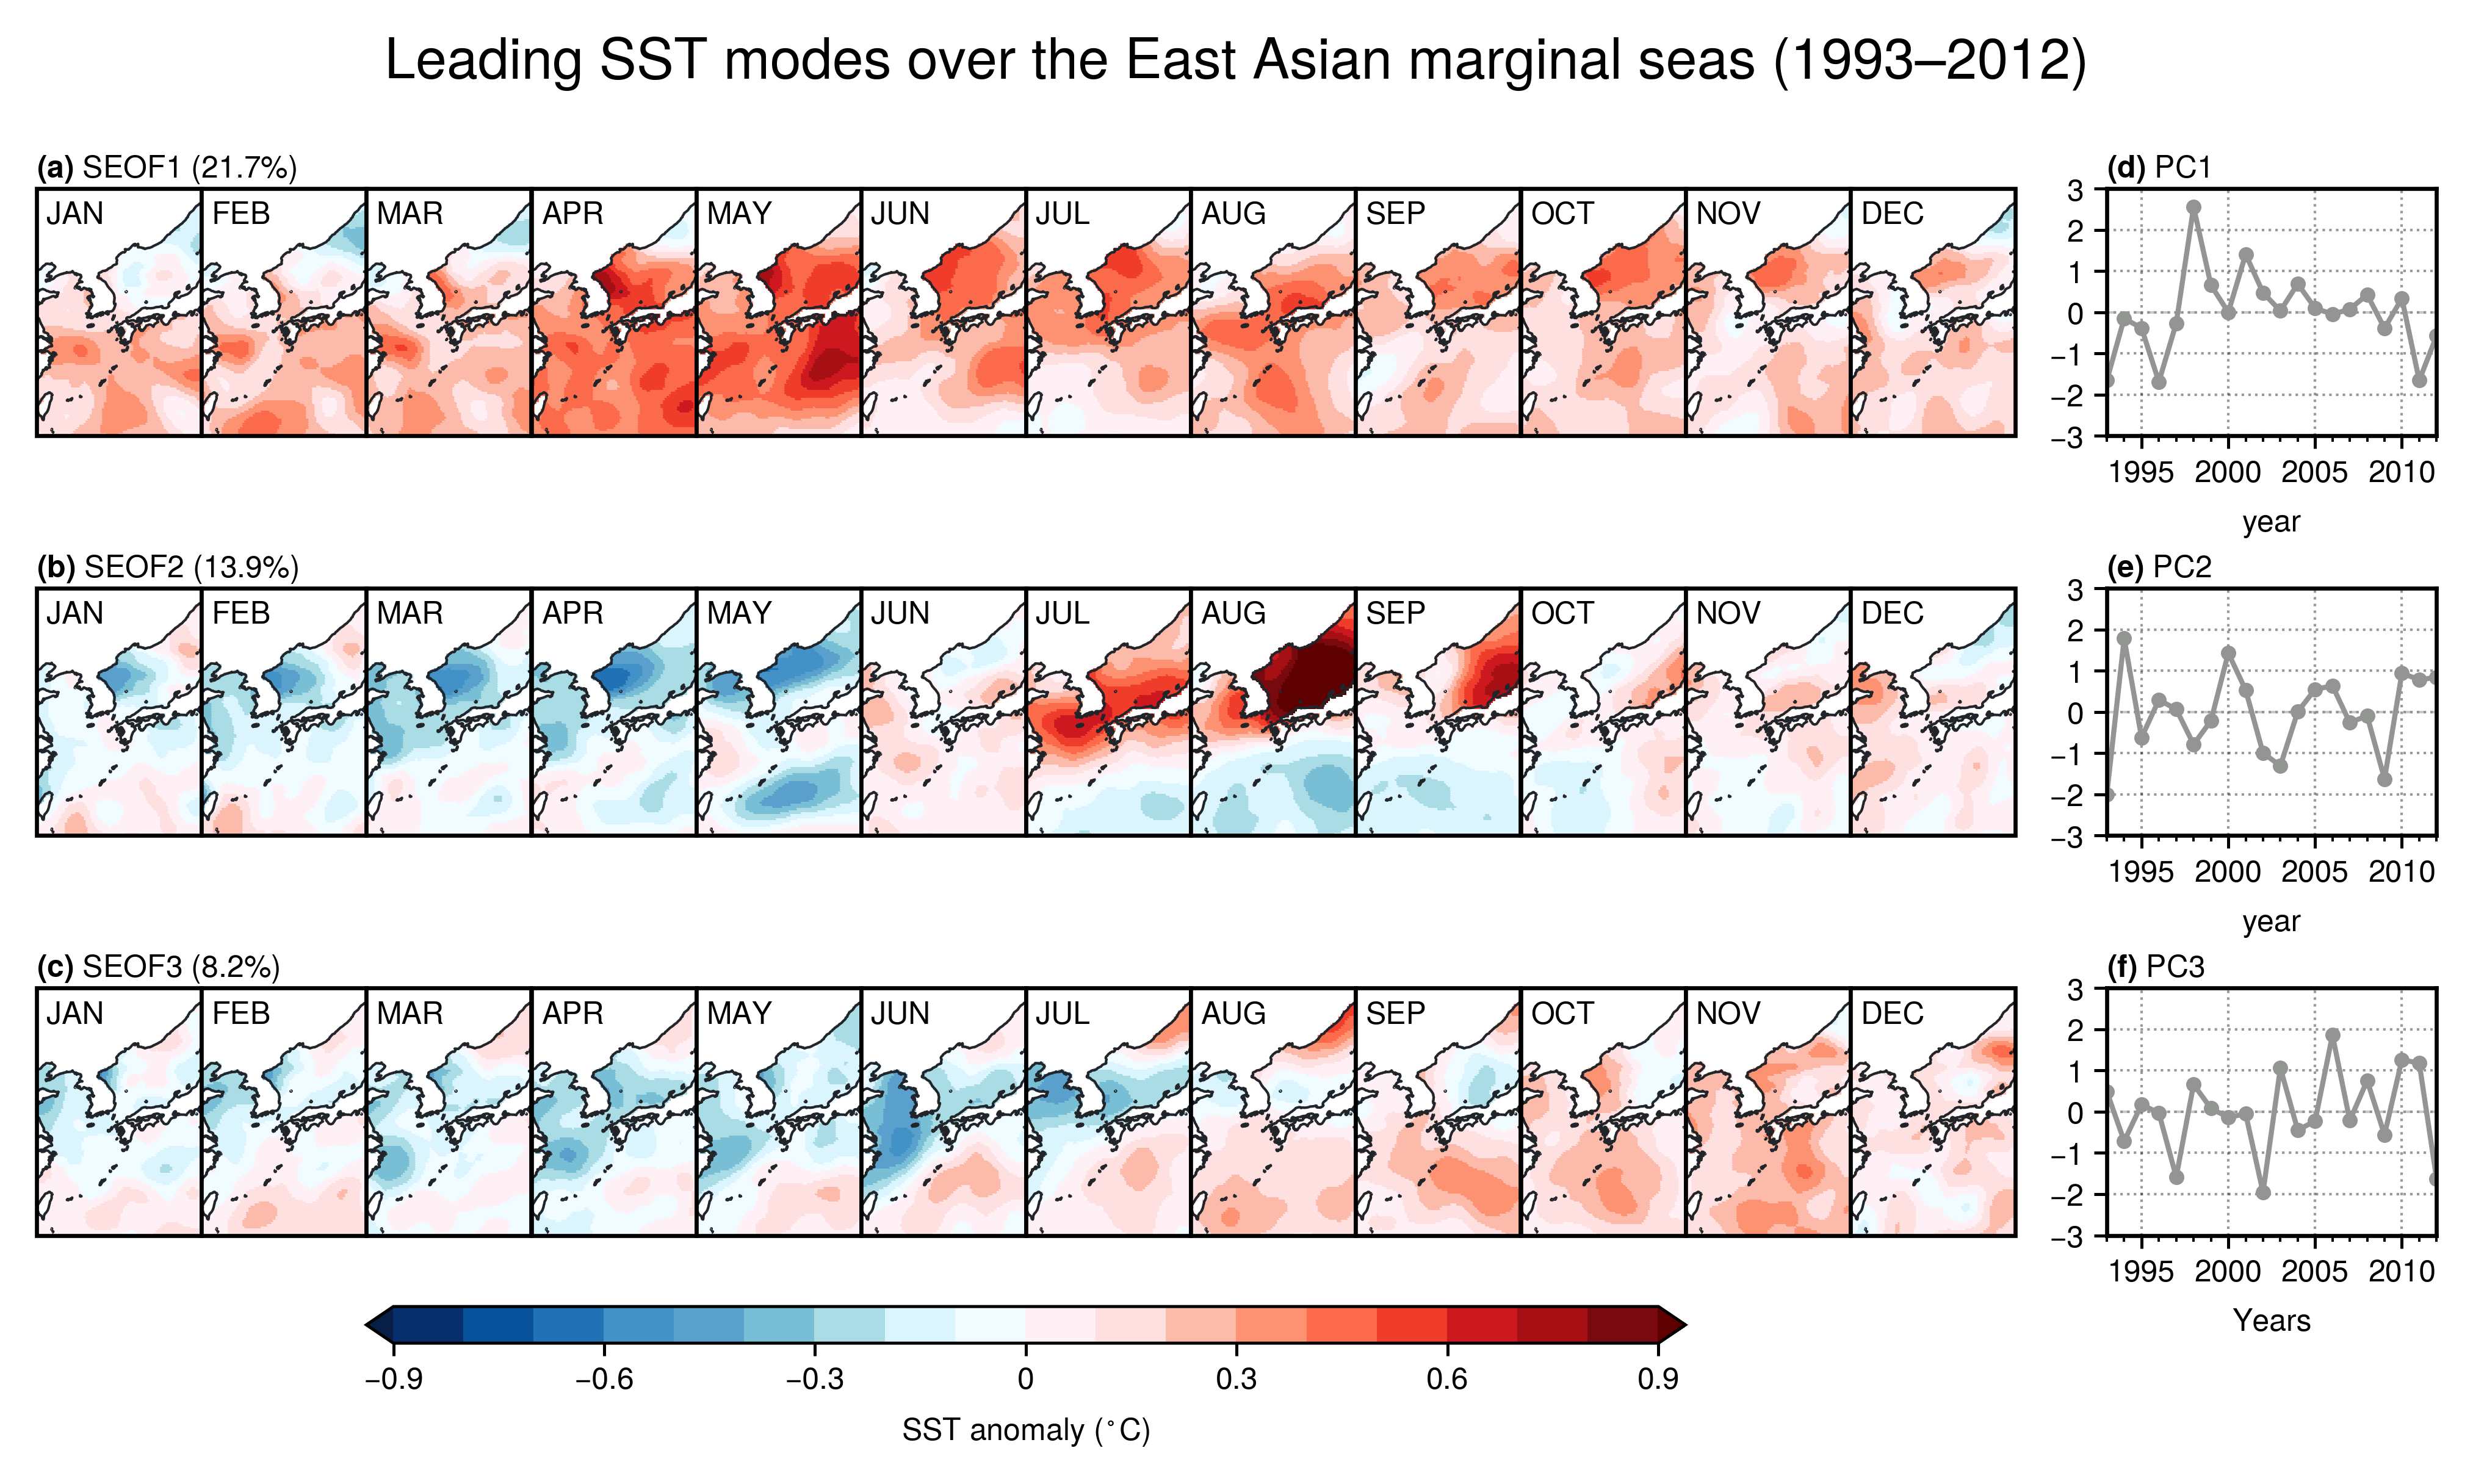

In [6]:
import proplot as pplt
import cmaps
import string

BASE_FONT_SIZE = 10
SMALL_FONT = BASE_FONT_SIZE - 4
MID_FONT = BASE_FONT_SIZE - 2.5

pplt.rc.update({
    "figure.dpi": 300,
    "figure.facecolor": "white",
    "savefig.transparent": False,
    "savefig.bbox": "tight",
    "font.family": "sans-serif",
    "font.size": BASE_FONT_SIZE,
    "axes.titlesize": SMALL_FONT,
    "axes.labelsize": SMALL_FONT,
    "xtick.labelsize": SMALL_FONT,
    "ytick.labelsize": SMALL_FONT,
    "legend.fontsize": SMALL_FONT,
    "grid.linewidth": 0.5,
    "grid.alpha": 0.4,
    "tick.len": 2.5,
})

cov = seof["covariance_patterns"].copy()
pc = seof["annual_pc_standardized"].copy()
variance_fractions = seof["explained_variance"]

# Reverse the sign of SEOF2 for visualization.
mode2 = cov.mode.values[1]
cov.loc[dict(mode=mode2)] *= -1
pc.loc[dict(mode=mode2)] *= -1

n_modes = int(cfg["seof"]["retained_modes"])
n_months = 12
n_map_axes = n_modes * n_months

syear = pd.Timestamp(training_period[0]).year
eyear = pd.Timestamp(training_period[1]).year

# Layout

map_array = np.arange(
    1,
    n_map_axes + 1,
).reshape(n_modes, n_months)

pc_ids = np.arange(
    n_map_axes + 1,
    n_map_axes + n_modes + 1,
).reshape(-1, 1)

# Make each PC panel two columns wide.
pc_columns = np.repeat(pc_ids, 2, axis=1)

parray = np.hstack((map_array, pc_columns))

wspace_list = [0] * (parray.shape[1] - 1)
wspace_list[n_months - 1] = 1.8

proj_list = (
    [pplt.Proj("cyl", lon_0=180)] * n_map_axes
    + [None] * n_modes
)

fig = pplt.figure(
    figwidth="17cm",
    tight=True,
    span=False,
    share=False,
    hspace=[3],
)

axs = fig.subplots(
    array=parray,
    proj=proj_list,
    wspace=wspace_list,
)

# Figure settings

latlim = tuple(cfg["domain"]["latitude"])
lonlim = tuple(cfg["domain"]["longitude"])

vmax = 0.9
clev = np.linspace(-vmax, vmax, 19)
cmap = cmaps.temp_19lev

en_dash = "\u2013"
suptitle = (
    "Leading SST modes over the East Asian marginal seas "
    f"({syear}{en_dash}{eyear})"
)

axs.format(
    suptitle=suptitle,
    suptitle_kw={"weight": "normal"},
    suptitlepad="1.2em",
    ec="black",
    lw=0.8,
    coast=True,
    coastlinewidth=0.5,
    coastcolor="grey9",
    reso="med",
    grid=False,
    gridminor=False,
    labels=False,
    latlim=latlim,
    lonlim=lonlim,
)

# Monthly covariance patterns

months = [
    "JAN", "FEB", "MAR", "APR", "MAY", "JUN",
    "JUL", "AUG", "SEP", "OCT", "NOV", "DEC",
]

for mode_idx, mode in enumerate(cov.mode.values):

    for month_idx, month in enumerate(cov.month.values):

        ax_idx = mode_idx * n_months + month_idx
        ax = axs[ax_idx]

        field = cov.sel(
            mode=mode,
            month=month,
        )

        m = ax.pcolormesh(
            field,
            levels=clev,
            cmap=cmap,
            extend="both",
        )

        ax.text(
            0.06,
            0.95,
            months[month_idx],
            transform=ax.transAxes,
            fontsize=SMALL_FONT,
            fontweight="normal",
            va="top",
        )

# SEOF titles

letters = list(string.ascii_lowercase)

for mode_idx, mode in enumerate(cov.mode.values):

    variance = float(
        variance_fractions.sel(mode=mode)
    )

    ax_idx = mode_idx * n_months

    axs[ax_idx].format(
        title=(
            rf"$\bf{{({letters[mode_idx]})}}$ "
            rf"SEOF{mode_idx + 1} "
            rf"({variance * 100:.1f}%)"
        ),
        titleloc="l",
        titleweight="normal",
        titlesize=SMALL_FONT,
        titlepad=2.3,
    )

# PC panels

for mode_idx, mode in enumerate(pc.mode.values):

    ax_idx = n_map_axes + mode_idx
    ax = axs[ax_idx]

    x = pc.sel(mode=mode).year
    y = pc.sel(mode=mode)

    ax.plot(
        x,
        y,
        lw=1,
        color="grey",
        marker="o",
        ms=2 * (20 / len(x)),
    )

    ax.axhline(
        0,
        color="gray",
        alpha=0.5,
        linewidth=0.5,
        linestyle="--",
    )

    ax.format(
        title=(
            rf"$\bf{{({letters[n_modes + mode_idx]})}}$ "
            rf"PC{mode_idx + 1}"
        ),
        titleloc="l",
        titleweight="normal",
        titlesize=SMALL_FONT,
        titlepad=2.3,
        ylim=(-3, 3),
        ylocator=1,
        xlocator=5,
        xminorlocator=1,
        yminorlocator="none",
        xgrid=True,
        ygrid=True,
        gridminor=False,
        gridstyle=":",
        gridlinewidth=0.5,
        ylabel="",
    )

    if mode_idx == n_modes - 1:
        ax.set_xlabel("Years")

# Colorbar

fig.colorbar(
    m,
    ticks=0.3,
    tickminor=False,
    alpha=0,
    label=r"SST anomaly ($^\circ$C)",
    loc="b",
    cols=(2, 11),
    length=0.8,
    pad=1.4,
    extendsize=0.5,
    width=0.1,
)

fig_path = (
    REPO_ROOT
    / cfg["figs"]["seof_modes"]
)

fig_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

fig.savefig(
    fig_path, 
    dpi=600,
)

fig.show()
